In [5]:
# Pricing & Deal Optimization — Product-Level Dataset

import pandas as pd
import numpy as np
from pathlib import Path

# Paths
BASE_DIR = Path("/home/niranjanrao07/cod-multiagent-ecommerce/data/processed")
REVIEW_PATH = BASE_DIR / "amazon_sentiment_subsets/amazon_sentiment_cleaned.parquet"
META_PATH = BASE_DIR / "amazon_product_meta/amazon_product_meta_cleaned.parquet"
OUTPUT_PATH = BASE_DIR / "amazon_pricing_analytics/amazon_pricing_ready.parquet"

# Load data
df_reviews = pd.read_parquet(REVIEW_PATH)
df_meta = pd.read_parquet(META_PATH)

print("Reviews:", df_reviews.shape, "Metadata:", df_meta.shape)

# Derive sentiment score (-1, 0, 1)
def sentiment_score(r):
    if r <= 2: return -1
    elif r == 3: return 0
    else: return 1

df_reviews["sentiment_score"] = df_reviews["rating"].apply(sentiment_score)

# Aggregate review-level signals by category
review_summary = (
    df_reviews.groupby("category")
    .agg(
        avg_sentiment=("sentiment_score", "mean"),
        avg_helpful=("helpful_vote", "mean"),
        review_count=("rating", "count")
    )
    .reset_index()
)

# Merge product metadata with category-level sentiment
df_final = df_meta.merge(review_summary, on="category", how="left")

# Fill and clean
df_final["avg_helpful"].fillna(0, inplace=True)
df_final["avg_sentiment"].fillna(0, inplace=True)
df_final["review_count"].fillna(0, inplace=True)

# Log-transform price for modeling stability
df_final["log_price"] = np.log1p(df_final["price"])

# Save product-level training dataset
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df_final.to_parquet(OUTPUT_PATH, index=False)

print(f"Saved pricing dataset: {OUTPUT_PATH}")
print("Shape:", df_final.shape)
print("\nSample:")
print(df_final.sample(5, random_state=42))


Reviews: (133730, 9) Metadata: (90000, 4)
Saved pricing dataset: /home/niranjanrao07/cod-multiagent-ecommerce/data/processed/amazon_pricing_analytics/amazon_pricing_ready.parquet
Shape: (90000, 8)

Sample:
                                                   title   price  \
89610                       the perfect cupcake a momoir   15.00   
12456  ausrialian gold smooth faces facial intensifie...   26.00   
53403  replacement for olympus stylus sz16 charger co...    5.99   
62905                              generation of victors    6.69   
66339                                we are for the dark  125.00   

       average_rating     category  avg_sentiment  avg_helpful  review_count  \
89610             4.8        Books       0.767799     2.981391         34875   
12456             4.6   All_Beauty       0.564764     0.977455         49812   
53403             4.3  Electronics       0.670656     1.456212         49043   
62905             3.0        Books       0.767799     2.981391   

/tmp/ipykernel_36823/316722052.py:42: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final["avg_helpful"].fillna(0, inplace=True)
/tmp/ipykernel_36823/316722052.py:43: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

Loaded: /home/niranjanrao07/cod-multiagent-ecommerce/data/processed/amazon_pricing_analytics/amazon_pricing_ready.parquet
Shape: (90000, 8)

Columns: ['title', 'price', 'average_rating', 'category', 'avg_sentiment', 'avg_helpful', 'review_count', 'log_price']

=== Numeric Summary ===
          price  average_rating  avg_sentiment  avg_helpful  review_count  \
count  90000.00        90000.00       90000.00     90000.00      90000.00   
mean      28.44            4.13           0.67         1.81      44576.67   
std      121.93            0.75           0.08         0.85       6867.33   
min        0.00            1.00           0.56         0.98      34875.00   
25%       14.99            3.80           0.56         0.98      34875.00   
50%       15.00            4.30           0.67         1.46      49043.00   
75%       15.84            4.60           0.77         2.98      49812.00   
max    12998.00            5.00           0.77         2.98      49812.00   

       log_price  
co

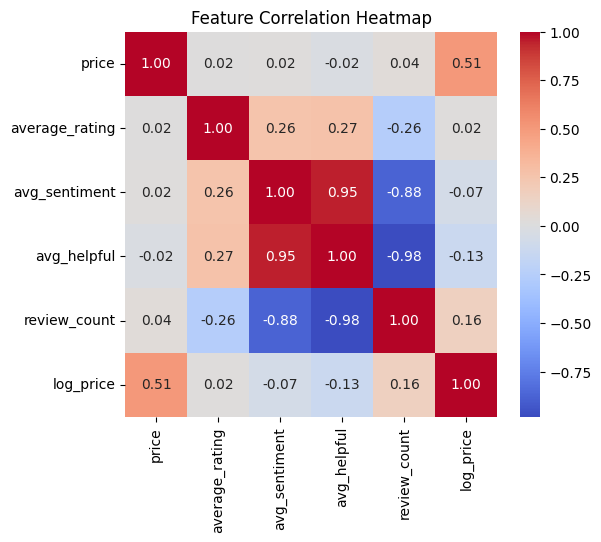

/tmp/ipykernel_36823/2615586735.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="category", y="price", palette="viridis")


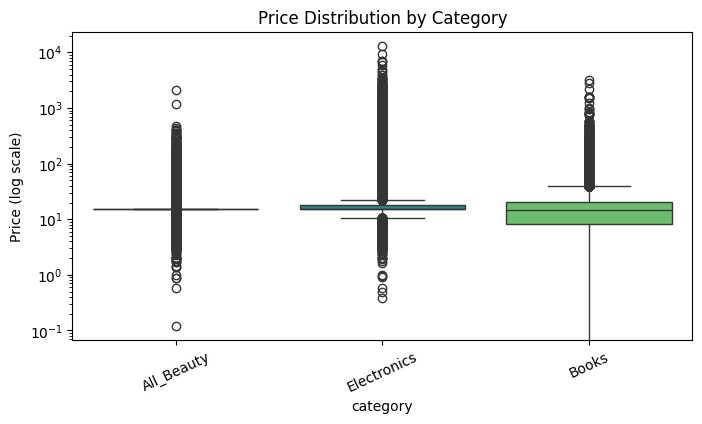

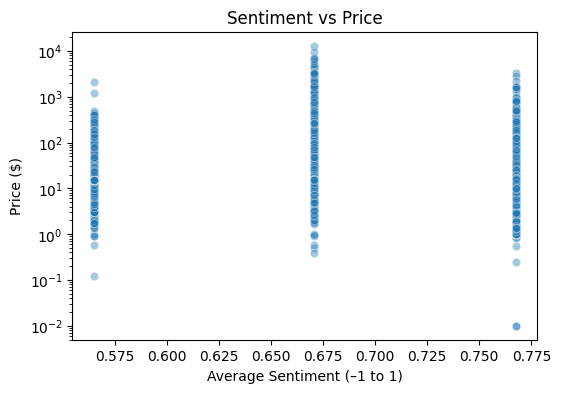


=== Category Summary ===
             avg_price  avg_rating  avg_sentiment
category                                         
All_Beauty       17.13        3.92           0.56
Books            21.27        4.40           0.77
Electronics      46.94        4.08           0.67


In [6]:
# Pricing Dataset EDA

import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_parquet(OUTPUT_PATH)
print("Loaded:", OUTPUT_PATH)
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))

# --- Basic overview ---
print("\n=== Numeric Summary ===")
print(df[["price", "average_rating", "avg_sentiment", "avg_helpful", "review_count", "log_price"]].describe().round(2))

# --- Correlation heatmap ---
plt.figure(figsize=(6, 5))
sns.heatmap(df[["price", "average_rating", "avg_sentiment", "avg_helpful", "review_count", "log_price"]].corr(), 
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# --- Price distribution by category ---
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="category", y="price", palette="viridis")
plt.title("Price Distribution by Category")
plt.yscale("log")
plt.ylabel("Price (log scale)")
plt.xticks(rotation=25)
plt.show()

# --- Sentiment vs price ---
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="avg_sentiment", y="price", alpha=0.4)
plt.title("Sentiment vs Price")
plt.xlabel("Average Sentiment (–1 to 1)")
plt.ylabel("Price ($)")
plt.yscale("log")
plt.show()

# --- Category summary ---
cat_summary = df.groupby("category").agg(
    avg_price=("price", "mean"),
    avg_rating=("average_rating", "mean"),
    avg_sentiment=("avg_sentiment", "mean")
).round(2)
print("\n=== Category Summary ===")
print(cat_summary)
